# Detector de Cancer o Tumor Cerebral 

Lucho Dic|2024 <br>
Au cafe de la paix by Thomas Fersen

## ¿Qué es un tumor cerebral?

Un tumor cerebral es una acumulación o masa de células anormales en el cerebro. Tu cráneo, que protege al cerebro, es muy rígido. Cualquier crecimiento dentro de un espacio tan restringido puede causar problemas. Los tumores cerebrales pueden ser cancerosos (malignos) o no cancerosos (benignos). Cuando los tumores benignos o malignos crecen, pueden provocar un aumento de la presión dentro del cráneo. Esto puede causar daño cerebral y poner en riesgo la vida.

---

### La importancia del tema

La detección y clasificación temprana de los tumores cerebrales es un área importante de investigación en el campo de la imagenología médica, y ayuda a seleccionar el método de tratamiento más adecuado para salvar la vida del paciente.

---

### Métodos

La aplicación de enfoques de aprendizaje profundo en el contexto del diagnóstico de salud está proporcionando soluciones impactantes. Según la Organización Mundial de la Salud (OMS), un diagnóstico adecuado de tumores cerebrales implica:

- La detección
- La identificación de la ubicación del tumor cerebral
- La clasificación del tumor según su malignidad, grado y tipo

Este trabajo experimental en el diagnóstico de tumores cerebrales utilizando Imágenes por Resonancia Magnética (IRM) implica:

- Detectar el tumor
- Clasificarlo en términos de grado y tipo
- Identificar su ubicación

Este método ha sido experimentado utilizando un solo modelo para clasificar IRM cerebrales en diferentes tareas de clasificación, en lugar de usar un modelo individual para cada tarea. 

La **clasificación multitarea basada en redes neuronales convolucionales (CNN)** permite la detección y clasificación de tumores. La identificación de la ubicación del tumor cerebral también se realiza mediante un modelo basado en CNN, segmentando el tumor cerebral.

---

### Sobre el conjunto de datos

Este conjunto de datos es una combinación de los siguientes tres conjuntos:

- **figshare**
- **SARTAJ dataset**
- **Br35H**

Este conjunto contiene **7023 imágenes de IRM del cerebro humano**, clasificadas en 4 clases:

- Glioma  
- Meningioma  
- Sin tumor  
- Pituitario

Las imágenes de la clase *sin tumor* fueron tomadas del conjunto de datos **Br35H**.

> **Nota:** Creo que el conjunto de datos **SARTAJ** tiene un problema, ya que las imágenes de la clase *glioma* no están categorizadas correctamente. Me di cuenta de esto por los resultados de otros trabajos, así como por los distintos modelos que entrené.  
> Por eso eliminé las imágenes de esa carpeta y utilicé las imágenes del sitio **figshare** en su lugar.

---

### Nota

Ten en cuenta que **el tamaño de las imágenes en este conjunto de datos es diferente**. Puedes redimensionarlas al tamaño deseado después de preprocesarlas y eliminar los márgenes sobrantes.  
Este trabajo mejorará la precisión del código de preprocesamiento del modelo.

---

Dataset: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset/data

## Import Packages

In [1]:


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os 

import random  
from PIL import Image, ImageEnhance 
from tensorflow.keras.preprocessing.image import load_img, img_to_array  
from tensorflow.keras.models import Sequential,load_model  
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  
from tensorflow.keras.optimizers import Adam  
from tensorflow.keras.applications import VGG16  
from sklearn.utils import shuffle  
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc,f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import label_binarize

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models



### Import Dataset

In [2]:
# Directorios de train y test
base_dir = 'F:/Proyectos/tumor_cerebral'
train_dir = os.path.join(base_dir, 'Training')
test_dir = os.path.join(base_dir, 'Testing')

In [3]:
# Cargar y mezclar aleatoriamente los datos de entrenamiento
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Cargar y mezclar aleatoriamente los datos de prueba
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


### Visualizacion de datos

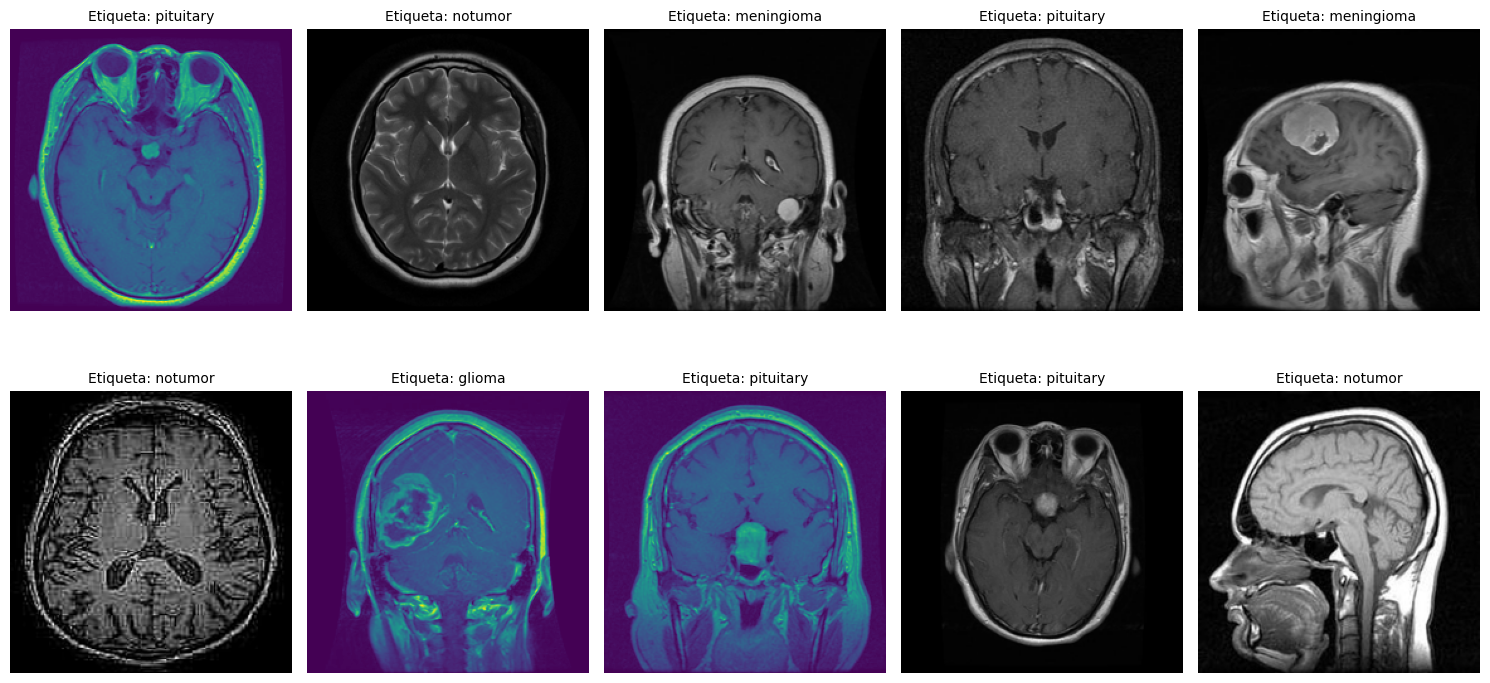

In [4]:
# Seleccionar índices aleatorios para 10 imágenes
random_indices = random.sample(range(len(train_paths)), 10)

# Crear una figura para mostrar las imágenes en 2 filas
fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()  # Aplanar la matriz de ejes para recorrerla fácilmente

for i, idx in enumerate(random_indices):
    # Cargar la imagen
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((224, 224))  # Redimensionar a un tamaño consistente

    # Mostrar la imagen
    axes[i].imshow(img)
    axes[i].axis('off')  # Ocultar los ejes
    # Mostrar la etiqueta de clase en el título
    axes[i].set_title(f"Etiqueta: {train_labels[idx]}", fontsize=10)

plt.tight_layout()  # Ajustar el diseño para que no se sobrepongan los elementos
plt.show()  # Mostrar la figura


#### Procesamiento Imagenes

In [5]:
# Función de aumento de imágenes (Image Augmentation)
def augment_image(image):
    image = Image.fromarray(np.uint8(image))  # Convertir el array en imagen PIL
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Brillo aleatorio
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Contraste aleatorio
    image = np.array(image) / 255.0  # Normalizar los valores de píxeles al rango [0, 1]
    return image

In [6]:
# Cargar imágenes y aplicar aumentación
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))  # Cargar imagen con tamaño fijo
        image = augment_image(image)  # Aplicar aumentación
        images.append(image)
    return np.array(images)  # Devolver como array de NumPy


In [7]:
# Codificación de etiquetas (convertir nombres de etiquetas a enteros)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Obtener etiquetas únicas desde el directorio de entrenamiento
    encoded = [unique_labels.index(label) for label in labels]  # Convertir etiquetas a índices
    return np.array(encoded)


In [8]:
# Generador de datos por lotes (batching)
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):  # Repetir por la cantidad de épocas
        for i in range(0, len(paths), batch_size):  # Iterar por lotes
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)  # Abrir y aumentar imágenes del lote
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)  # Codificar etiquetas del lote
            yield batch_images, batch_labels  # Devolver el lote (imagenes, etiquetas)


Estamos utilizando VGG16 para aprendizaje por transferencia.

El modelo está construido sobre VGG16, que es una red neuronal convolucional (CNN) preentrenada para la clasificación de imágenes.

<b>Primero</b>, se carga el modelo VGG16 con los parámetros `input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)`, `include_top=False` y `weights='imagenet'`.

- La forma de entrada (`input_shape`) se establece para que coincida con el tamaño de las imágenes del conjunto de datos, que es de 128x128 píxeles.
- El parámetro `include_top=False` indica que no se incluirán las capas completamente conectadas (fully-connected) finales de VGG16 que realizan la clasificación.
- El parámetro `weights='imagenet'` significa que el modelo estará preentrenado con un conjunto de datos de 1.4 millones de imágenes llamado ImageNet.

A continuación, se utiliza el bucle `for layer in base_model.layers:` para establecer todas las capas del `base_model` (VGG16) como no entrenables, de modo que los pesos de estas capas no se actualizarán durante el entrenamiento.

Luego, se configuran las últimas tres capas del modelo VGG16 como entrenables usando:  
`base_model.layers[-2].trainable = True`,  
`base_model.layers[-3].trainable = True` y  
`base_model.layers[-4].trainable = True`.

Después de eso, se crea un modelo secuencial y se añade el modelo VGG16 con `model.add(base_model)`.

A continuación, se añade una capa `Flatten` al modelo con `model.add(Flatten())`, la cual transforma la salida del modelo VGG16 de un tensor 3D a un tensor 1D, para que pueda ser procesado por las siguientes capas del modelo.

Luego, se añade una capa `Dropout` con `model.add(Dropout(0.3))`, que se utiliza para prevenir el sobreajuste al poner en cero aleatoriamente una fracción de las unidades de entrada en cada actualización durante el entrenamiento.

Después, se añade una capa densa (`Dense`) con 128 neuronas y función de activación `relu` usando `model.add(Dense(128, activation='relu'))`.

A continuación, se añade otra capa `Dropout` con `model.add(Dropout(0.2))`.

Finalmente, se añade la capa de salida densa con un número de neuronas igual al número de etiquetas únicas y función de activación `softmax` con  
`model.add(Dense(len(unique_labels), activation='softmax'))`.  

La función de activación `softmax` se usa para proporcionar una distribución de probabilidad sobre las posibles clases.

In [9]:
# Arquitectura del modelo
IMAGE_SIZE = 128  # Tamaño de la imagen (ajústalo según tus requerimientos)
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Congelar todas las capas del modelo base VGG16
for layer in base_model.layers:
    layer.trainable = False

# Hacer entrenables las últimas capas del modelo base VGG16
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Construir el modelo final
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))  # Capa de entrada
model.add(base_model)  # Añadir el modelo base VGG16
model.add(Flatten())  # Aplanar la salida del modelo base
model.add(Dropout(0.3))  # Capa Dropout para regularización
model.add(Dense(128, activation='relu'))  # Capa densa con activación ReLU
model.add(Dropout(0.2))  # Capa Dropout para regularización
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))  # Capa de salida con activación softmax

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,763,908 (60.13 MB)

 Trainable params: 8,128,644 (31.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [10]:
# Parámetros
batch_size = 20
steps = int(len(train_paths) / batch_size)  # Pasos por época
epochs = 5  # Número de épocas

# Entrenar el modelo
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)

Epoch 1/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 372s 1s/step - loss: 0.4465 - sparse_categorical_accuracy: 0.8316
Epoch 2/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 359s 1s/step - loss: 0.2319 - sparse_categorical_accuracy: 0.9100
Epoch 3/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - loss: 0.1543 - sparse_categorical_accuracy: 0.9422
Epoch 4/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - loss: 0.1173 - sparse_categorical_accuracy: 0.9570
Epoch 5/5
285/285 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - loss: 0.0936 - sparse_categorical_accuracy: 0.9656


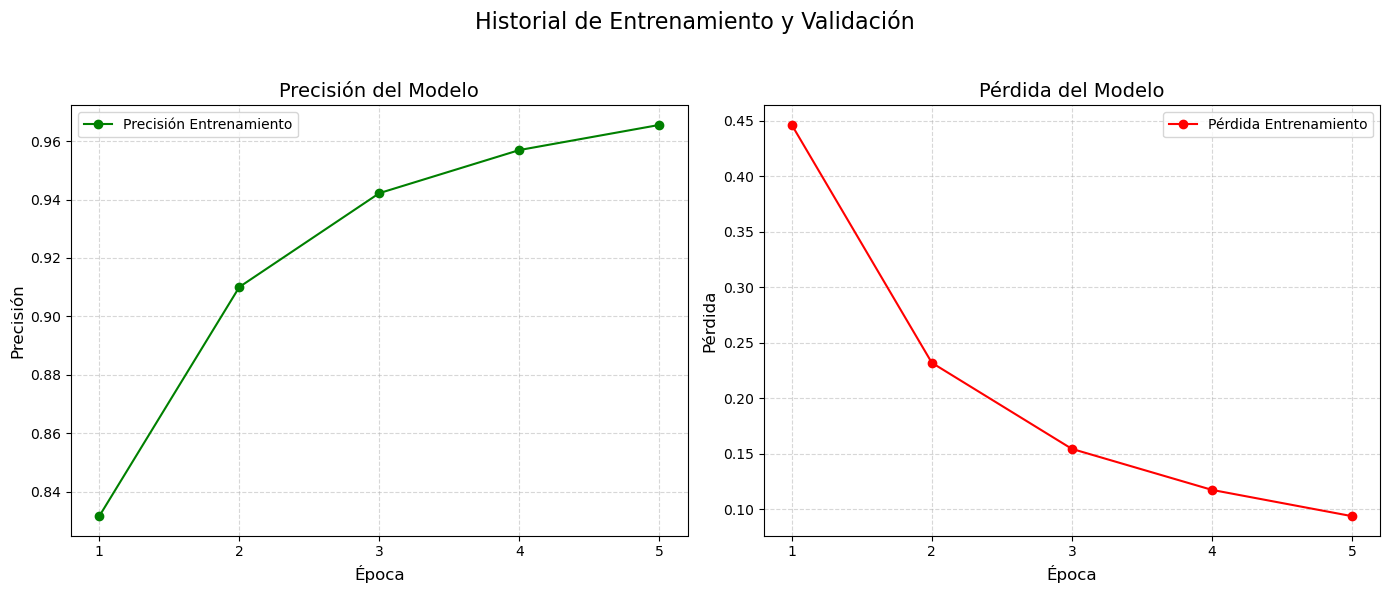

In [11]:
def graficar_historial_entrenamiento(history, epochs):
    acc = history.history['sparse_categorical_accuracy']
    loss = history.history['loss']
    val_acc = history.history.get('val_sparse_categorical_accuracy')
    val_loss = history.history.get('val_loss')

    epochs_range = range(1, epochs + 1)

    plt.figure(figsize=(14, 6))

    # --- Precisión ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, 'o-', color='green', label='Precisión Entrenamiento')
    if val_acc:
        plt.plot(epochs_range, val_acc, 'o-', color='blue', label='Precisión Validación')

        # Mejor precisión en validación
        mejor_acc_epoca = np.argmax(val_acc) + 1
        mejor_acc = val_acc[mejor_acc_epoca - 1]
        plt.axvline(mejor_acc_epoca, color='blue', linestyle='--', alpha=0.7,
                    label=f'Mej. Precisión (Época {mejor_acc_epoca})')
        plt.annotate(f'{mejor_acc:.2f}', xy=(mejor_acc_epoca, mejor_acc),
                     xytext=(mejor_acc_epoca, mejor_acc + 0.02),
                     arrowprops=dict(facecolor='blue', arrowstyle='->'),
                     fontsize=10)

    plt.title('Precisión del Modelo', fontsize=14)
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Precisión', fontsize=12)
    plt.xticks(epochs_range)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    # --- Pérdida ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, 'o-', color='red', label='Pérdida Entrenamiento')
    if val_loss:
        plt.plot(epochs_range, val_loss, 'o-', color='orange', label='Pérdida Validación')

        # Menor pérdida en validación
        mejor_loss_epoca = np.argmin(val_loss) + 1
        mejor_loss = val_loss[mejor_loss_epoca - 1]
        plt.axvline(mejor_loss_epoca, color='orange', linestyle='--', alpha=0.7,
                    label=f'Menor Pérdida (Época {mejor_loss_epoca})')
        plt.annotate(f'{mejor_loss:.4f}', xy=(mejor_loss_epoca, mejor_loss),
                     xytext=(mejor_loss_epoca, mejor_loss + 0.02),
                     arrowprops=dict(facecolor='orange', arrowstyle='->'),
                     fontsize=10)

    plt.title('Pérdida del Modelo', fontsize=14)
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Pérdida', fontsize=12)
    plt.xticks(epochs_range)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.suptitle('Historial de Entrenamiento y Validación', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

graficar_historial_entrenamiento(history, epochs)

In [12]:
# Predicción sobre los datos de prueba
imagenes_test = open_images(test_paths)  # Cargar y procesar las imágenes de prueba
etiquetas_test_codificadas = encode_label(test_labels)  # Codificar las etiquetas verdaderas

# Realizar predicciones con el modelo entrenado
predicciones_test = model.predict(imagenes_test)

print(classification_report(etiquetas_test_codificadas, np.argmax(predicciones_test, axis=1)))

41/41 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       300
           1       0.93      0.93      0.93       306
           2       0.98      0.99      0.99       405
           3       1.00      0.93      0.96       300

    accuracy                           0.96      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.96      0.96      0.96      1311



📉 Matriz de Confusión:
[[290  10   0   0]
 [ 15 285   5   1]
 [  4   1 400   0]
 [  8  12   2 278]]


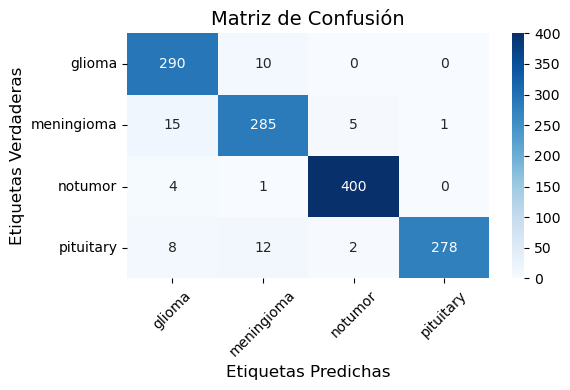

In [13]:
# Matriz de Confusión
etiquetas_reales = etiquetas_test_codificadas
etiquetas_predichas = np.argmax(predicciones_test, axis=1)

matriz_confusion = confusion_matrix(etiquetas_reales, etiquetas_predichas)

print("📉 Matriz de Confusión:")
print(matriz_confusion)

# Obtener nombres de las clases desde el directorio de entrenamiento
nombres_clases = sorted(os.listdir(train_dir))  # Asegura orden consistente

# Graficar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.title("Matriz de Confusión", fontsize=14)
plt.xlabel("Etiquetas Predichas", fontsize=12)
plt.ylabel("Etiquetas Verdaderas", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

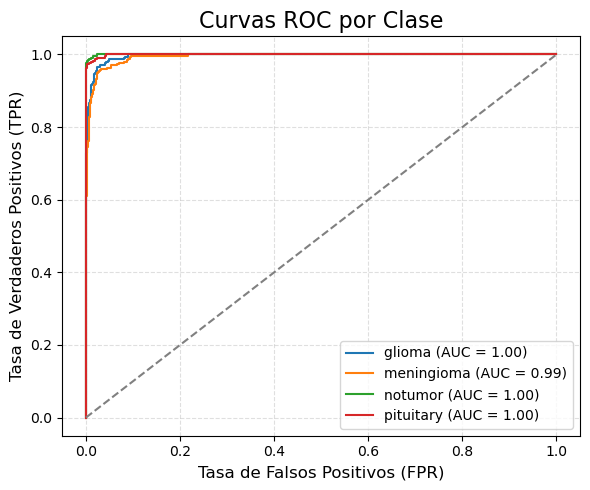

In [14]:
# Codificar etiquetas verdaderas en formato binarizado
etiquetas_binarias_test = label_binarize(etiquetas_test_codificadas, classes=np.arange(len(os.listdir(train_dir))))
probabilidades_predichas = predicciones_test  # Probabilidades por clase

# Calcular FPR, TPR y AUC para cada clase
fpr, tpr, auc_por_clase = {}, {}, {}
num_clases = etiquetas_binarias_test.shape[1]

for i in range(num_clases):
    fpr[i], tpr[i], _ = roc_curve(etiquetas_binarias_test[:, i], probabilidades_predichas[:, i])
    auc_por_clase[i] = auc(fpr[i], tpr[i])

# Obtener nombres de clases
nombres_clases = sorted(os.listdir(train_dir))

# Graficar las curvas ROC por clase
plt.figure(figsize=(6, 5))

for i in range(num_clases):
    plt.plot(fpr[i], tpr[i], label=f'{nombres_clases[i]} (AUC = {auc_por_clase[i]:.2f})')

# Línea diagonal (modelo aleatorio)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title('Curvas ROC por Clase', fontsize=16)
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

##### Guardar Modelo

In [15]:
# Save the entire model
model.save('model.h5')

##### Verificacion

In [16]:
model = load_model('model.h5')

In [17]:
# Class labels
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error al procesar imagen:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step


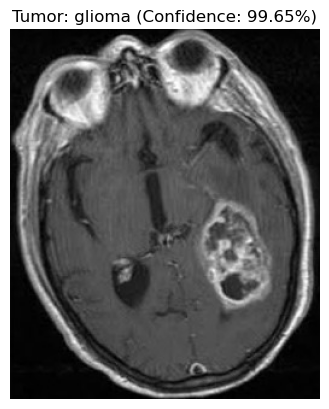

In [18]:
image_path = 'F:/Proyectos/tumor_cerebral/Testing/meningioma/Te-meTr_0001.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


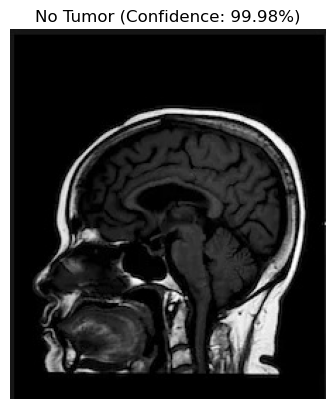

In [19]:
image_path = 'F:/Proyectos/tumor_cerebral/Testing/notumor/Te-noTr_0004.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


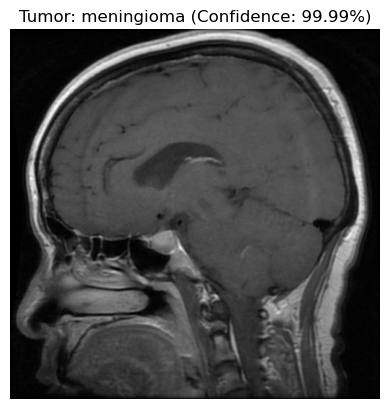

In [20]:
image_path = 'F:/Proyectos/tumor_cerebral/Testing/pituitary/Te-piTr_0003.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


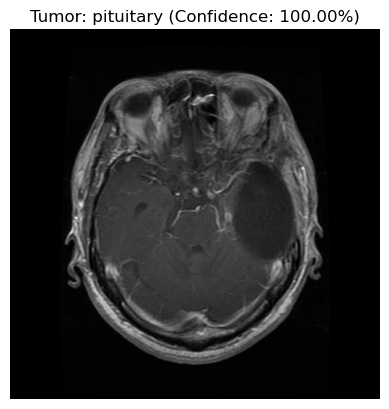

In [21]:
image_path = 'F:/Proyectos/tumor_cerebral/Testing/glioma/Te-gl_0015.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)